# Knowledge Discovery in Databases (KDD) Project: Formula 1 Race Outcome
**Obiettivo del Progetto:** Applicare l'intero processo KDD al dataset ufficiale "Formula 1 World Championship (1950-2023)" di Kaggle. L'obiettivo è estrarre conoscenza per prevedere se una vettura concluderà la gara in zona punti (Top 10) conoscendo solo i parametri pre-partenza: posizione in griglia, scuderia e circuito. L'analisi si concentra sull'era turbo-ibrida (dal 2014 ad oggi).

In [1]:
# ==============================================================================
# FASE 1: DATA SELECTION & INTEGRATION
# Estrazione dei dati grezzi e integrazione relazionale per definire il dominio.
# ==============================================================================

import os
import warnings
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Soppressione dei warning per mantenere l'output pulito in fase di presentazione
warnings.filterwarnings('ignore')

print("FASE 1: DATA SELECTION & INTEGRATION")

# 1. Estrazione automatizzata tramite API (garantisce la riproducibilità senza dataset in locale)
dataset_path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

try:
    # Caricamento mirato delle sole tabelle relazionali strettamente necessarie all'analisi
    results = pd.read_csv(os.path.join(dataset_path, 'results.csv'))
    races = pd.read_csv(os.path.join(dataset_path, 'races.csv'))
    constructors = pd.read_csv(os.path.join(dataset_path, 'constructors.csv'))
except Exception as e:
    print(f"Errore critico I/O durante il caricamento CSV: {e}")

# 2. Data Integration (Join Relazionale in cascata)
# Mappiamo i risultati ai metadati della gara (anno, circuito) e ai costruttori.
# L'uso del Left Join preserva l'integrità dei record della tabella 'results' principale.
df_merged = results.merge(
    races[['raceId', 'year', 'circuitId', 'name']], 
    on='raceId', 
    how='left'
)
df_merged = df_merged.merge(
    constructors[['constructorId', 'name']], 
    on='constructorId', 
    how='left', 
    suffixes=('_race', '_constructor')
)

# 3. Temporal Scoping (Restrizione del Dominio)
# Isoliamo esclusivamente l'Era Turbo-Ibrida (dal 2014 a oggi). Questa scelta ingegneristica 
# garantisce la coerenza tecnologica del dataset, rimuovendo il rumore statistico 
# generato dai cambi di regolamento delle ere precedenti (es. V8, V10, rifornimenti).
df_modern = df_merged[df_merged['year'] >= 2014].copy()

print(f"Dimensioni dataset integrato (Era Ibrida): {df_modern.shape}")
df_modern.head()

FASE 1: DATA SELECTION & INTEGRATION
Dimensioni dataset integrato (Era Ibrida): (4626, 22)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,circuitId,name_race,name_constructor
22127,22130,900,3,131,6,3,1,1,1,25.0,...,5578710,19,1,1:32.478,206.436,1,2014,1,Australian Grand Prix,Mercedes
22128,22131,900,825,1,20,4,2,2,2,18.0,...,5605487,49,6,1:33.066,205.131,1,2014,1,Australian Grand Prix,McLaren
22129,22132,900,18,1,22,10,3,3,3,15.0,...,5608737,39,5,1:32.917,205.460,1,2014,1,Australian Grand Prix,McLaren
22130,22133,900,4,6,14,5,4,4,4,12.0,...,5613994,57,7,1:33.186,204.867,1,2014,1,Australian Grand Prix,Ferrari
22131,22134,900,822,3,77,15,5,5,5,10.0,...,5626349,56,3,1:32.616,206.128,1,2014,1,Australian Grand Prix,Williams


## Fase 2: Data Pre-processing
In questa fase puliamo i dati, gestiamo le anomalie e definiamo la nostra variabile target. Il dataset di F1 di Kaggle utilizza la stringa `\N` per i valori mancanti; dobbiamo gestirla. Inoltre, creeremo la variabile binaria `target_points` (1 se il pilota arriva in Top 10, 0 altrimenti).

FASE 2: DATA PRE-PROCESSING & LEAKAGE PREVENTION


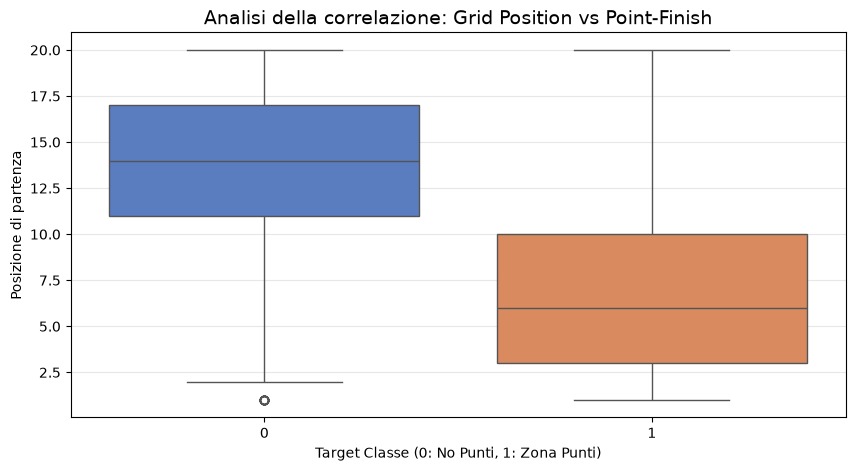

Pipeline di pre-processing completata. Record validi per il training: 4477


In [2]:
# ==============================================================================
# FASE 2: DATA PRE-PROCESSING & LEAKAGE PREVENTION
# Definizione del target, pulizia del dataset e messa in sicurezza contro il Data Leakage.
# ==============================================================================

print("FASE 2: DATA PRE-PROCESSING & LEAKAGE PREVENTION")

# 1. Definizione della Variabile Target (Binary Classification)
# Trasformiamo la variabile continua 'positionOrder' in un target binario (1: Zona Punti, 0: Fuori Zona Punti).
df_modern['target_points'] = (df_modern['positionOrder'] <= 10).astype(int)

# 2. Feature Selection & Leakage Prevention (Cruciale)
# Per rendere il modello predittivo in fase pre-gara, escludiamo esplicitamente feature 'post-race' 
# come 'time', 'status' o 'laps'. L'inclusione di queste variabili causerebbe Data Leakage, 
# fornendo al modello informazioni che per definizione non sono note al momento del via.
features = ['grid', 'circuitId', 'name_constructor', 'target_points']
df_model = df_modern[features].copy()

# 3. Data Cleaning & Anomalies Handling
# Normalizzazione dei valori nulli rappresentati nel dataset originale come stringhe "\\N".
df_model.replace(r'\\N', np.nan, regex=True, inplace=True)
df_model.dropna(inplace=True)

# Filtro di validità: consideriamo solo partenze in griglia tra la 1ª e la 20ª posizione.
# Le partenze dalla pit-lane (grid=0) o posizioni non valide vengono rimosse per evitare distorsioni nel modello.
df_model = df_model[(df_model['grid'] > 0) & (df_model['grid'] <= 20)]

# 4. Exploratory Data Analysis (EDA)
# Analisi della distribuzione della feature 'grid' rispetto al target per visualizzare 
# la correlazione tra posizione di partenza e probabilità di arrivare in zona punti.
plt.figure(figsize=(10, 5))
sns.boxplot(x='target_points', y='grid', data=df_model, palette='muted')
plt.title("Analisi della correlazione: Grid Position vs Point-Finish", fontsize=14)
plt.xlabel("Target Classe (0: No Punti, 1: Zona Punti)")
plt.ylabel("Posizione di partenza")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Pipeline di pre-processing completata. Record validi per il training: {len(df_model)}")

## Fase 3: Data Transformation
Prepariamo i dati per l'algoritmo di Machine Learning. 
1. **One-Hot Encoding**: Trasformiamo le variabili categoriche (circuito e scuderia) in variabili dummy (binarie).
2. **Train/Test Split**: Dividiamo il dataset (80% addestramento, 20% test).
3. **Scaling**: Standardizziamo la posizione in griglia per uniformare le distribuzioni.

In [3]:
# ==============================================================================
# FASE 3: DATA TRANSFORMATION & FEATURE ENGINEERING
# Trasformazione delle variabili categoriche e standardizzazione del dominio numerico.
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("FASE 3: DATA TRANSFORMATION")

# 1. Categorical Encoding (One-Hot Encoding)
# Trasformiamo le feature nominali ('name_constructor', 'circuitId') in un set di feature binarie.
# drop_first=True è essenziale per evitare la 'Dummy Variable Trap' (multicollinearità perfetta).
df_transformed = pd.get_dummies(df_model, columns=['name_constructor', 'circuitId'], drop_first=True)

# 2. Separazione del Target (y) dalle Feature (X)
X = df_transformed.drop('target_points', axis=1)
y = df_transformed['target_points']

# 3. Stratified Data Splitting
# Effettuiamo una divisione stratificata (80/20). La stratificazione assicura che la 
# distribuzione percentuale della classe target (arrivo in punti) sia identica sia 
# nel set di addestramento che in quello di test, garantendo una valutazione imparziale.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

# 4. Feature Scaling (Standardization)
# Applichiamo la standardizzazione Z-score esclusivamente alla variabile continua 'grid'.
# Fitting del scaler solo sul training set per evitare Data Leakage statistico, 
# applicando poi la trasformazione anche al set di test.
scaler = StandardScaler()
X_train['grid'] = scaler.fit_transform(X_train[['grid']])
X_test['grid'] = scaler.transform(X_test[['grid']])

print(f"Dimensioni Training Set: {X_train.shape}")
print(f"Dimensioni Testing Set: {X_test.shape}")

FASE 3: DATA TRANSFORMATION
Dimensioni Training Set: (3581, 51)
Dimensioni Testing Set: (896, 51)


## Fase 4: Data Mining
Utilizziamo l'algoritmo **Random Forest Classifier** per estrarre pattern di successo. Scegliamo un modello a ensemble perché è molto robusto e gestisce bene dataset con molte variabili codificate in One-Hot (come le scuderie e i circuiti).

In [4]:
# ==============================================================================
# FASE 4: DATA MINING (MODEL TRAINING)
# Addestramento dell'algoritmo di Ensemble Learning per l'estrazione di pattern predittivi.
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier

print("FASE 4: DATA MINING - RANDOM FOREST")

# Inizializzazione del classificatore Random Forest.
# - n_estimators=100: Definizione dell'ampiezza dell'ensemble per ridurre la varianza.
# - max_depth=10: Regolarizzazione della profondità degli alberi per prevenire l'overfitting 
#   (evitando che il modello impari a memoria il noise del training set).
# - class_weight='balanced': Tecnica di penalizzazione per bilanciare il peso delle classi, 
#   fondamentale data la distribuzione non perfettamente uniforme tra arrivi a punti e fuori punti.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# Fitting del modello: fase di estrazione dei pattern logici dal training set.
rf_model.fit(X_train, y_train)

# Generazione dell'inferenza sul test set (dati mai visti dal modello).
y_pred = rf_model.predict(X_test)

print("Addestramento completato: Pattern stocastici estratti con successo.")

FASE 4: DATA MINING - RANDOM FOREST
Addestramento completato: Pattern stocastici estratti con successo.


## Fase 5: Evaluation and Interpretation
Valutiamo la bontà del modello. Analizzeremo la Matrice di Confusione e le metriche principali: **Accuracy, Precision e Recall**. Vogliamo capire quanto il nostro modello sia affidabile nel prevedere chi andrà a punti conoscendo solo la griglia e il team.

FASE 5: EVALUATION AND INTERPRETATION


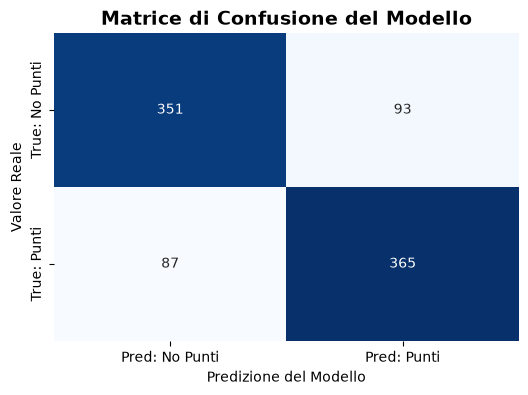


--- PERFORMANCE METRICS SUMMARY ---
Global Accuracy: 79.91%
Precision Score: 79.69%
Recall Score:    80.75%
F1-Score:        80.22%


In [5]:
# ==============================================================================
# FASE 5: EVALUATION AND INTERPRETATION
# Analisi quantitativa delle prestazioni tramite matrici di confusione e metriche.
# ==============================================================================

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("FASE 5: EVALUATION AND INTERPRETATION")

# 1. Matrice di Confusione
# Strumento fondamentale per visualizzare il comportamento del modello in termini di
# True Negatives (TN), False Positives (FP), False Negatives (FN) e True Positives (TP).
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: No Punti', 'Pred: Punti'],
            yticklabels=['True: No Punti', 'True: Punti'])
plt.title('Matrice di Confusione del Modello', fontweight='bold', fontsize=14)
plt.ylabel('Valore Reale')
plt.xlabel('Predizione del Modello')
plt.show()

# 2. Sintesi delle metriche di performance
# Utilizziamo l'F1-Score come metrica principale, essendo la media armonica tra precision e recall.
# È la metrica più robusta in presenza di classi non perfettamente bilanciate.
print("\n--- PERFORMANCE METRICS SUMMARY ---")
print(f"Global Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision Score: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall Score:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:        {f1_score(y_test, y_pred)*100:.2f}%")

## Fase 6: Use of Discovered Knowledge
Implementiamo un **Decision Support System (DSS)** per ingegneri di pista. Creiamo una funzione in cui inseriamo i parametri del nostro weekend di gara per prevedere in tempo reale se la nostra strategia di qualifica (posizione in griglia) sarà sufficiente per finire a punti con la nostra scuderia.

In [11]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import os

# ==============================================================================
# FASE 6: DECISION SUPPORT SYSTEM (DSS) - INTERACTIVE INFERENCE
# Implementazione di un'interfaccia reattiva per l'inferenza in tempo reale.
# ==============================================================================

print("FASE 6: DECISION SUPPORT SYSTEM (DSS)")

# 1. Ottimizzazione Ingegneristica (Anti-Lag Architecture)
# Creazione di un template statico pre-allineato con lo spazio delle feature (X.columns).
# Questa strategia permette di iniettare i nuovi dati nell'input senza dover ricostruire 
# il DataFrame o rieseguire il get_dummies ad ogni interazione, riducendo drasticamente la latenza.
template_aligned = pd.DataFrame(0, index=[0], columns=X.columns)

# Mapping relazionale per migliorare l'UX (trasformiamo gli ID in nomi leggibili)
try:
    circuits_df = pd.read_csv(os.path.join(dataset_path, 'circuits.csv'))
    circuit_map = circuits_df.set_index('circuitId')['location'].to_dict()
except Exception:
    circuit_map = {}

def simula_gara_veloce(grid_position, constructor_name, circuit_id):
    """
    Motore di inferenza veloce. Esegue la proiezione dei dati di input nel 
    vettore dello spazio delle feature e calcola la probabilità di successo.
    """
    if not (1 <= grid_position <= 20):
        print("Errore: Posizione in griglia non valida (Range 1-20).")
        return
    
    # Inserimento dei dati nel template pre-allocato
    input_aligned = template_aligned.copy()
    
    # Trasformazione della variabile numerica tramite il medesimo scaler usato nel training
    input_aligned['grid'] = scaler.transform([[grid_position]])[0][0]
    
    # Mapping diretto dei flag binari (Encoding manuale rapido)
    col_costruttore = f'name_constructor_{constructor_name}'
    col_circuito = f'circuitId_{circuit_id}'
    
    if col_costruttore in input_aligned.columns: input_aligned[col_costruttore] = 1
    if col_circuito in input_aligned.columns: input_aligned[col_circuito] = 1
        
    # Calcolo della probabilità (Inference)
    prob = rf_model.predict_proba(input_aligned)[0][1]
    citta = circuit_map.get(circuit_id, 'Località Sconosciuta')
    
    # Output del Decision Support System
    print("-" * 50)
    print(f"DSS ANALYTICS | Scuderia: '{constructor_name}' @ {citta} | Grid: P{grid_position}")
    print(f"Probabilità Zona Punti: {prob*100:.1f}%")
    print("ESITO: " + ("ZONA PUNTI" if prob >= 0.5 else "FUORI PUNTI"))
    print("-" * 50)

# ==============================================================================
# UI CONFIGURATION (WIDGETS)
# ==============================================================================
scuderie_disponibili = sorted(df_model['name_constructor'].unique().tolist())
circuiti_opzioni = [(f"{cid} - {circuit_map.get(cid, 'Località Sconosciuta')}", cid) 
                    for cid in sorted(df_model['circuitId'].unique().tolist())]

# Slider con continuous_update=False: previene sovraccarichi di calcolo durante lo slide
grid_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Griglia:', continuous_update=False)
scuderia_dropdown = widgets.Dropdown(options=scuderie_disponibili, description='Scuderia:')
circuito_dropdown = widgets.Dropdown(options=circuiti_opzioni, description='Circuito:')

def aggiorna_predizione(grid, scuderia, circuito):
    simula_gara_veloce(grid, scuderia, circuito)

# Visualizzazione UI
widgets.interact(aggiorna_predizione, grid=grid_slider, scuderia=scuderia_dropdown, circuito=circuito_dropdown);

FASE 6: DECISION SUPPORT SYSTEM (DSS)


interactive(children=(IntSlider(value=5, continuous_update=False, description='Griglia:', max=20, min=1), Drop…